In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats


# Plotting
set_matplotlib_formats("retina")

plt.style.use(
    "https://raw.githubusercontent.com/"
    "ksingh1121/python-plot-style/main/physics.mplstyle"
)

In [2]:
# ============================================================
# CELL 1 — Initialize SLM + camera and load correction file
#
# Important:
#   wavefront_phase is ONLY a NumPy array at this stage.
#   It is NOT yet installed as an SLM correction.
# ============================================================

from pathlib import Path
import numpy as np

from slmsuite.hardware.slms.meadowlark import Meadowlark
from slmsuite.hardware.cameras.alliedvision import AlliedVision
from slmsuite.hardware.cameraslms import FourierSLM


# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------

SDK_PATH = Path(
    r"C:\Program Files\Meadowlark Optics\Blink 1920 HDMI\SDK"
)

LUT_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\Experiment scripts"
    r"\LUT_locked_759nm_20260811_201109\759nm_KS_global_20260811.lut"
)

WAVEFRONT_PHASE_PATH = Path(
    r"C:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts"
    r"\YDFC_wavefront_phase_processed_R2p80_50ms_dark.npy"
)


# ------------------------------------------------------------
# Initialize hardware ONCE in this notebook
# ------------------------------------------------------------

slm = Meadowlark(
    slm_number=1,
    sdk_path=str(SDK_PATH),
    lut_path=str(LUT_PATH),
    wav_um=0.7593,
    verbose=True,
)

cam = AlliedVision(
    serial="015C2",
    verbose=True,
)

fs = FourierSLM(cam, slm)


# ------------------------------------------------------------
# Load the measured correction from disk
#
# This only creates a NumPy array called wavefront_phase.
# It does NOT activate the correction.
# ------------------------------------------------------------

wavefront_phase = np.load(WAVEFRONT_PHASE_PATH)


# ------------------------------------------------------------
# Inspect our starting state
# ------------------------------------------------------------

print("SLM shape:", slm.shape)
print("Camera shape:", cam.shape)

print("\nLoaded correction:")
print(" shape :", wavefront_phase.shape)
print(" finite:", np.all(np.isfinite(wavefront_phase)))
print(" min   :", wavefront_phase.min())
print(" max   :", wavefront_phase.max())

print("\nCurrent slm.source keys:")
print(slm.source.keys())

print("\nGlobal default slm.phase_correct:")
print(slm.phase_correct)

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_header.py:30: UserWarning: cupy is not installed; using numpy. Install cupy for faster GPU-based holography.
  warnings.warn(


Validating DPI awareness...success
Constructing Blink SDK...success
Loading LUT file...vmbpy initializing... success
Looking for cameras... success
vmbpy sn '015C2' initializing... success
SLM shape: (1200, 1920)
Camera shape: (3672, 5496)

Loaded correction:
 shape : (1200, 1920)
 finite: True
 min   : 0.0
 max   : 6.2831762207757835

Current slm.source keys:
dict_keys([])

Global default slm.phase_correct:
True


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\hardware\cameras\camera.py:444: UserWarning: '015C2' _get_image_hw() failed 5 times before quitting.
  warnings.warn(f"'{self.name}' _get_image_hw() failed {failures} times before quitting.")


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from slmsuite.holography.algorithms import FeedbackHologram

In [4]:
cal_file = r"c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5"

loaded = fs.load_calibration(
    "fourier",
    file_path=cal_file
)

print("Loaded:", loaded)
print("Current calibrations:", fs.calibrations.keys())

print("Current calibrations:")
print(fs.calibrations.keys())

Loaded: c:\Users\admin\Desktop\Projects\SLM\SLM tests\Scripts\4f alignment scripts\YDFC_fourier_pre_wavefront_00000.h5
Current calibrations: dict_keys(['fourier'])
Current calibrations:
dict_keys(['fourier'])


In [5]:
print("M =")
print(fs.calibrations["fourier"]["M"])

print("\na =")
print(fs.calibrations["fourier"]["a"])

print("\nb =")
print(fs.calibrations["fourier"]["b"])

M =
[[-1.06337229e+05 -1.41055175e+02]
 [ 2.79442892e+01  1.04398063e+05]]

a =
[[0]
 [0]]

b =
[[4366.83233079]
 [1826.79508478]]


In [6]:
import numpy as np

zero_ij = np.asarray(fs.kxyslm_to_ijcam((0, 0))).reshape(-1)

x0 = float(zero_ij[0])
y0 = float(zero_ij[1])

print("0th order position:")
print("x0 =", x0)
print("y0 =", y0)

0th order position:
x0 = 4366.832330787704
y0 = 1826.7950847761629


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

H, W = fs.cam.shape

# OpenCV drawing canvas must be uint8
target_u8 = np.zeros((H, W), dtype=np.uint8)

# Put A away from zeroth order
cx = int(x0 - 700)
cy = int(y0)

text = "A"
font = cv2.FONT_HERSHEY_SIMPLEX
font_scale = 12
thickness = 30

(text_w, text_h), baseline = cv2.getTextSize(
    text,
    font,
    font_scale,
    thickness
)

origin = (
    int(cx - text_w / 2),
    int(cy + text_h / 2)
)

cv2.putText(
    target_u8,
    text,
    origin,
    font,
    font_scale,
    255,
    thickness,
    cv2.LINE_AA
)

# Convert to normalized float for slmsuite
target_ij = target_u8.astype(np.float32) / 255.0

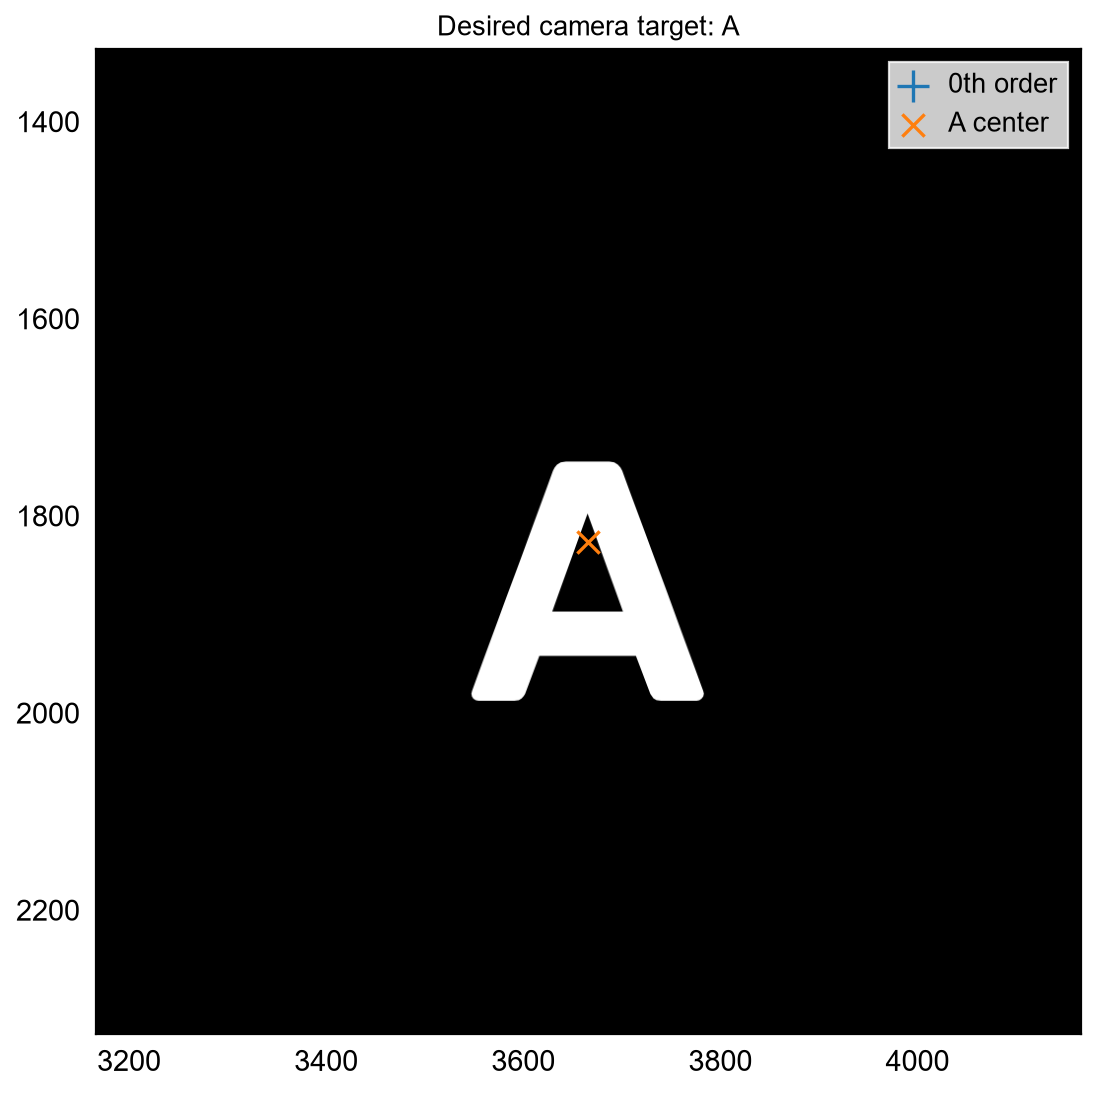

In [8]:
plt.figure(figsize=(10, 8))
plt.imshow(target_ij, cmap="gray", origin="upper")

plt.scatter(x0, y0, marker="+", s=200, label="0th order")
plt.scatter(cx, cy, marker="x", s=100, label="A center")

plt.xlim(cx - 500, cx + 500)
plt.ylim(cy + 500, cy - 500)

plt.legend()
plt.title("Desired camera target: A")
plt.show()

In [9]:
from slmsuite.holography.algorithms import FeedbackHologram

holo_A = FeedbackHologram(
    shape=fs.slm.shape,
    target_ij=target_ij,
    cameraslm=fs
)

print("Hologram object created.")
print("SLM shape:", fs.slm.shape)
print("Target shape:", target_ij.shape)

Hologram object created.
SLM shape: (1200, 1920)
Target shape: (3672, 5496)


c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:379: UserWarning: Hologram target shape (1200, 1920) is not a power of 2; consider using .get_padded_shape() to pad to powers of 2 and speed up FFT computation. While some FFT solvers support other prime powers (3, 5, 7, ...), literature suggests that GPU support is best for powers of 2.
  warnings.warn(


In [10]:
holo_A.reset_phase(quadratic_phase=2)

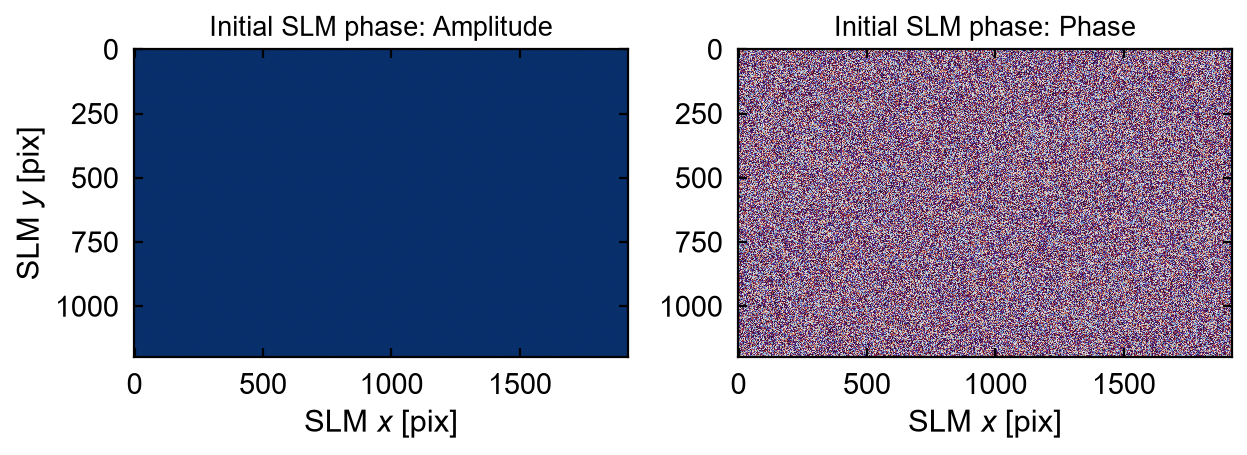

In [11]:
holo_A.plot_nearfield(title="Initial SLM phase")

In [12]:
print(fs.cam)

In [13]:
holo_A.optimize(
    method="WGS-Leonardo",
    maxiter=20,
    feedback="computational",
    stat_groups=["computational"]
)

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\admin\AppData\Local\Python\pythoncore-3.12-64\Lib\site-packages\slmsuite\holography\algorithms\_hologram.py:1837: RuntimeWarning: divide by zero encountered in divide
  xp.divide(feedback_corrected, xp.array(target_amp, copy=(False if np.__version__[0] == '1' else None)), out=feedback_corrected)


In [14]:
phase_A = holo_A.get_phase()

print("Phase shape:", phase_A.shape)
print("All values finite:", np.all(np.isfinite(phase_A)))
print("Number of NaNs:", np.isnan(phase_A).sum())
print("Number of infinities:", np.isinf(phase_A).sum())

Phase shape: (1200, 1920)
All values finite: True
Number of NaNs: 0
Number of infinities: 0


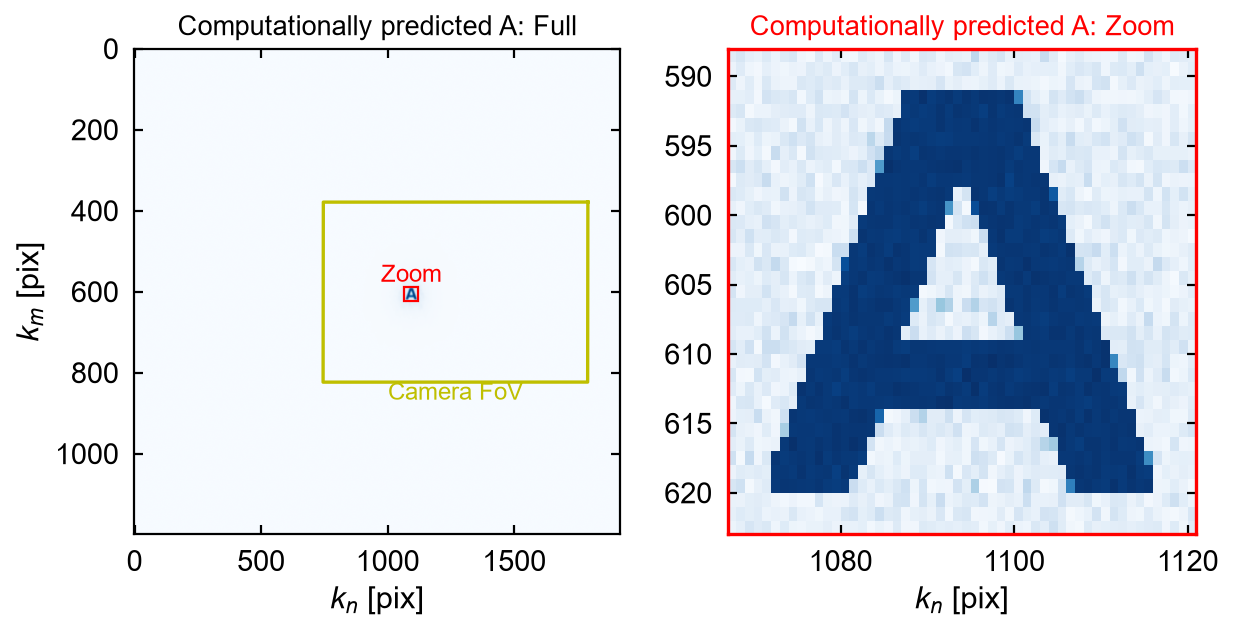

[array([1067, 1121]), array([588, 623])]

In [15]:
holo_A.plot_farfield(
    title="Computationally predicted A"
)

In [16]:
phase_A = holo_A.get_phase()

fs.slm.set_phase(
    phase_A,
    settle=True
)

array([[148, 130, 111, ..., 204, 185, 167],
       [148, 130, 111, ..., 204, 185, 167],
       [149, 130, 112, ..., 204, 185, 167],
       ...,
       [148, 129, 110, ..., 203, 184, 166],
       [148, 129, 111, ..., 203, 185, 166],
       [148, 130, 111, ..., 203, 185, 167]],
      shape=(1200, 1920), dtype=uint8)

In [17]:
fs.cam.flush()
img = fs.cam.get_image()

print("Image shape:", img.shape)
print("Min:", img.min())
print("Max:", img.max())

Image shape: (3672, 5496)
Min: 0
Max: 255


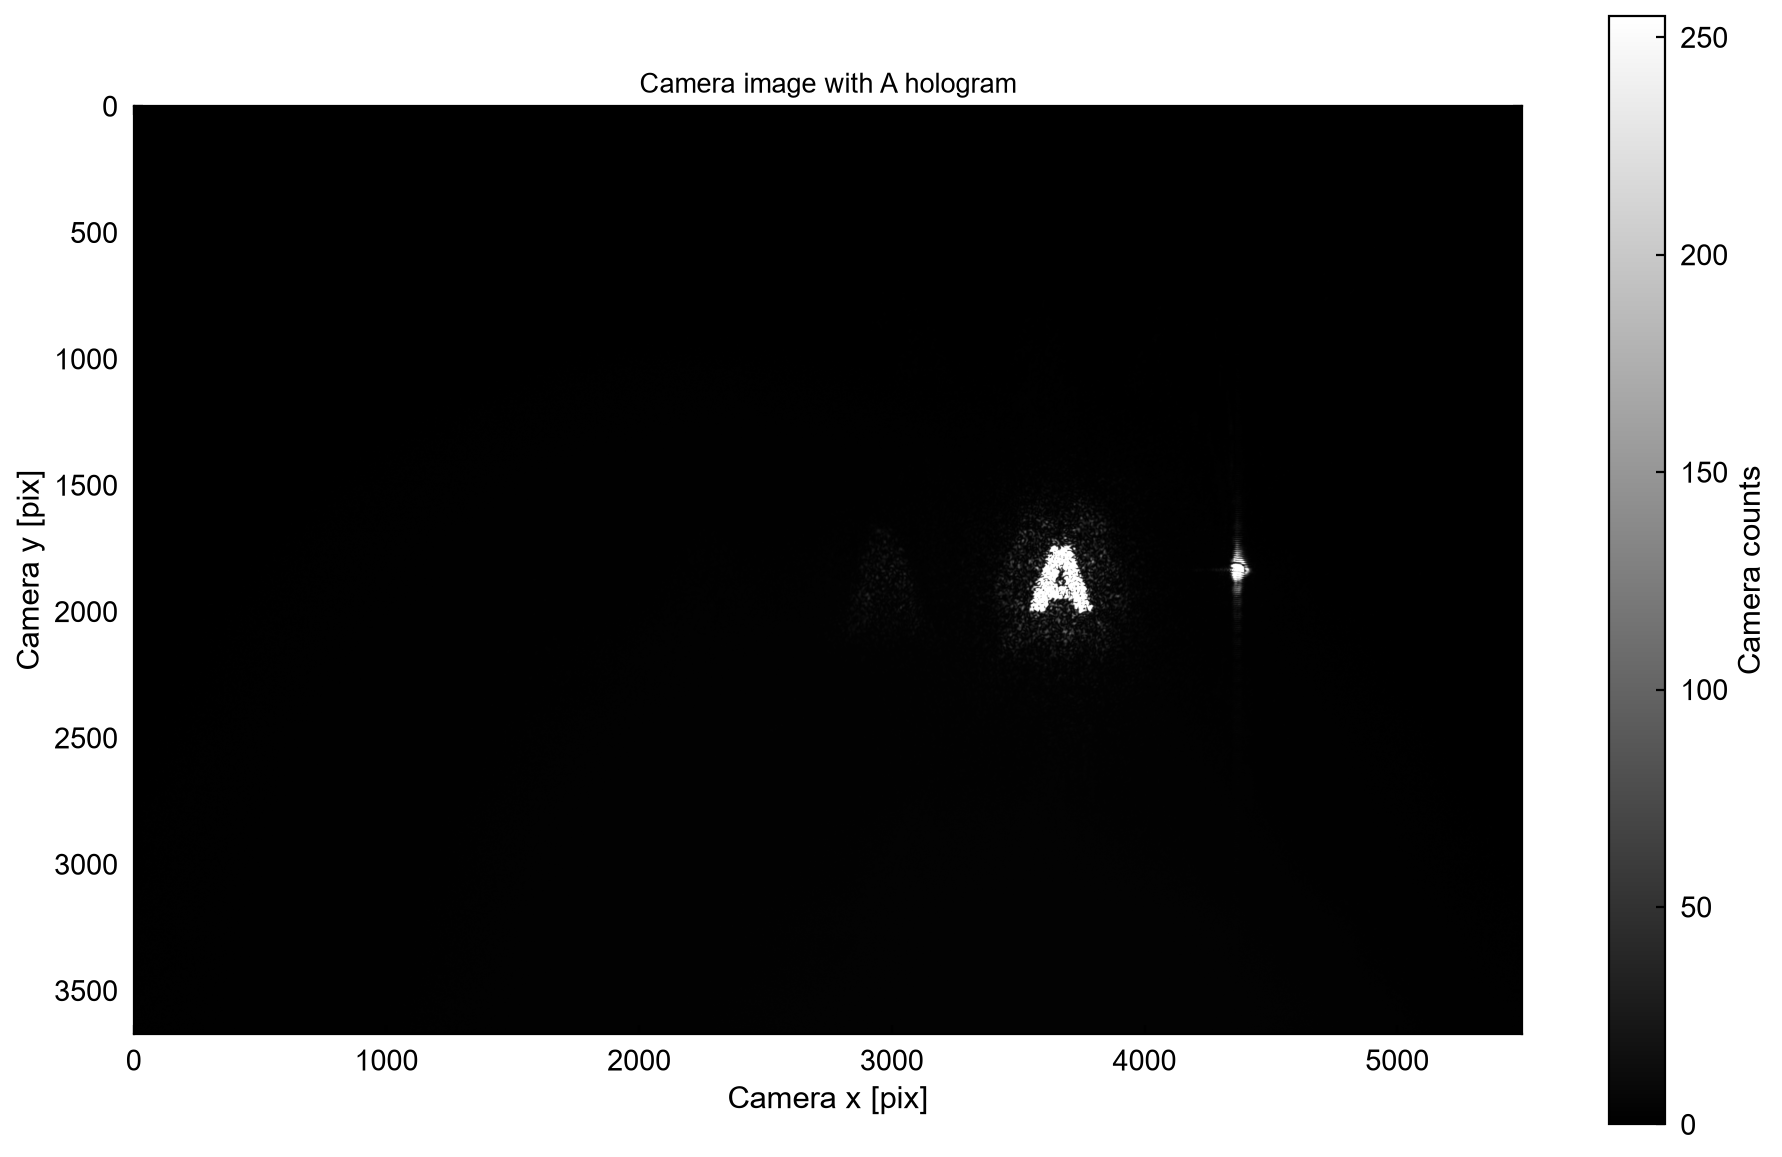

In [18]:
plt.figure(figsize=(14, 9))

plt.imshow(
    img,
    cmap="gray",
    origin="upper"
)

plt.colorbar(label="Camera counts")
plt.title("Camera image with A hologram")
plt.xlabel("Camera x [pix]")
plt.ylabel("Camera y [pix]")

plt.show()